### **4.2 Forecasting a Moving Average Process**

We will be working with **daily electricity sales data** (in GWh) from **August 2005 to November 2006**. This dataset captures electricity demand patterns over time - ideal for understanding MA behaviour.

---

**Data Overview**

- File: `AnnualElectricitySalesMA.csv`
- Date format: `yyyy-mm-dd`
- Variable: `Sales(GWh)` - daily electricity sales in giga watt hours (float)

**Source**: Adapted from [AER: Daily Contract Prices and Traded Volumes in South Australia](https://www.aer.gov.au/industry/registers/charts/daily-q1-base-contract-prices-and-traded-volumes-south-australia)

**Libraries Used**

- `statsmodels.tsa` - for building autoregressive time series models
- `matplotlib` - for visualising the data and forecasts

**Responsible AI Principles**

Before applying the model, reflect on the ethical use of data:

- Where is the data from, and who collected it?

- Are there any **privacy risks**?

- Does the data include **protected attributes** (e.g. gender, income, etc.)

- Which features are **observed, unobserved**, and what is the **outcome**?

- Could the data introduce **bias**? If so, consider how to mitigate it before modelling.

This helps ensure that our forecasting is **not only accurate**, but also **fair and responsible**.

**Model Identification Flow**

The diagram below outlines the decision process for identifying whether a time series follows an **autoregressive (AR)**, **moving average (MA)**, or **random walk** pattern. It guides you through checking for **stationarity**, examining **autocorrelation** via ACF and PACF plots, and selecting the appropriate model based on where the autocorrelations become non-significant.

<img src="Id_MAq_process.png" alt="Autoregression Model Identification" width="700">

**Step 1: Import all the libraries, read the data and explore observed data**


In [2]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller         # for stationarity testing
from statsmodels.tsa.statespace.sarimax import SARIMAX # for advanced modelling
from statsmodels.graphics.tsaplots import plot_acf     # for autocorrelation plots
from statsmodels.graphics.tsaplots import plot_pacf    # for partial autocorrelation plots

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning tools from the scikit-learn library
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Read the dataset
df = pd.read_csv("./data/AnnualElectricitySalesMA.csv", parse_dates=['Date'], index_col='Date')

In [4]:
# Display the first few rows of the dataset
df.head()

,Sales
Date,
2005-07-02,505.0
2005-07-03,508.1
2005-07-04,514.8
2005-07-05,535.4
2005-07-06,548.7


Plot the data to verify whether any evident patterns can be observed.

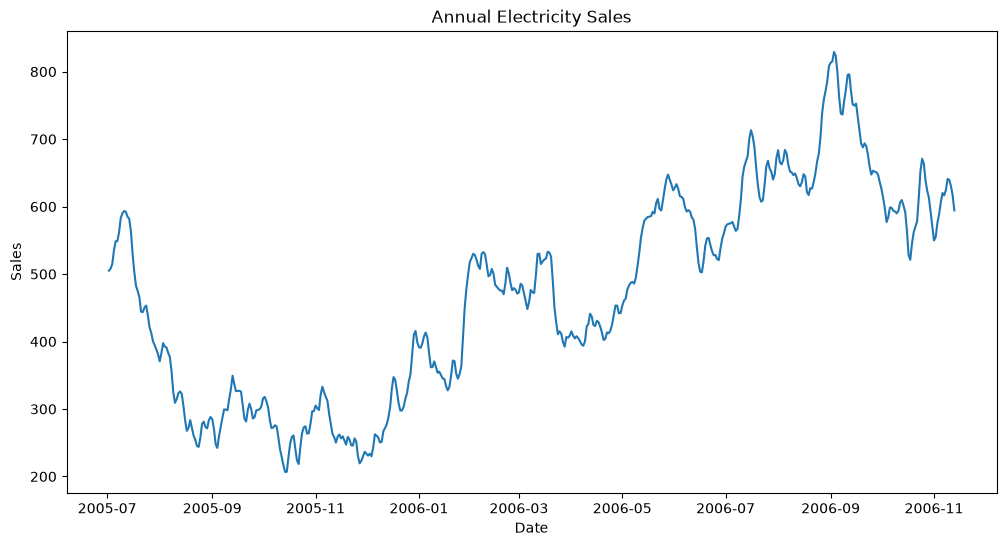

In [5]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Annual Electricity Sales')
plt.show()

**What do you observe in this graph?**
- Is it stationary process?
- Does it show a trend?
- Does it show seasonality?

**Step 2: Test for Stationarity**

If you look at the graph, it gives us an idea that it is not a stationary process but we still need to use ADF test to be sure.

In [6]:
ADF_result = adfuller(df['Sales'])
print(f'{"ADF Statistic":<15} {ADF_result[0]:>10.4f}')
print(f'{"p-value":<15} {ADF_result[1]:>10.4f}')

ADF Statistic      -1.5124
p-value             0.5274


We can see that the ADF test result ($p\gt0.05$) shows us that the time series is not stationary. We cannot reject the null hypothesis that a **unit root exists**.

---

**Importance of performing the ADF test**

---

**`regression` parameter in adfuller()**

**Step 3: First-order Differencing**

Since the time series is not stationary, we apply transformation (first-order differencing).

In [7]:
sales_diff = np.diff(df['Sales'], n=1)

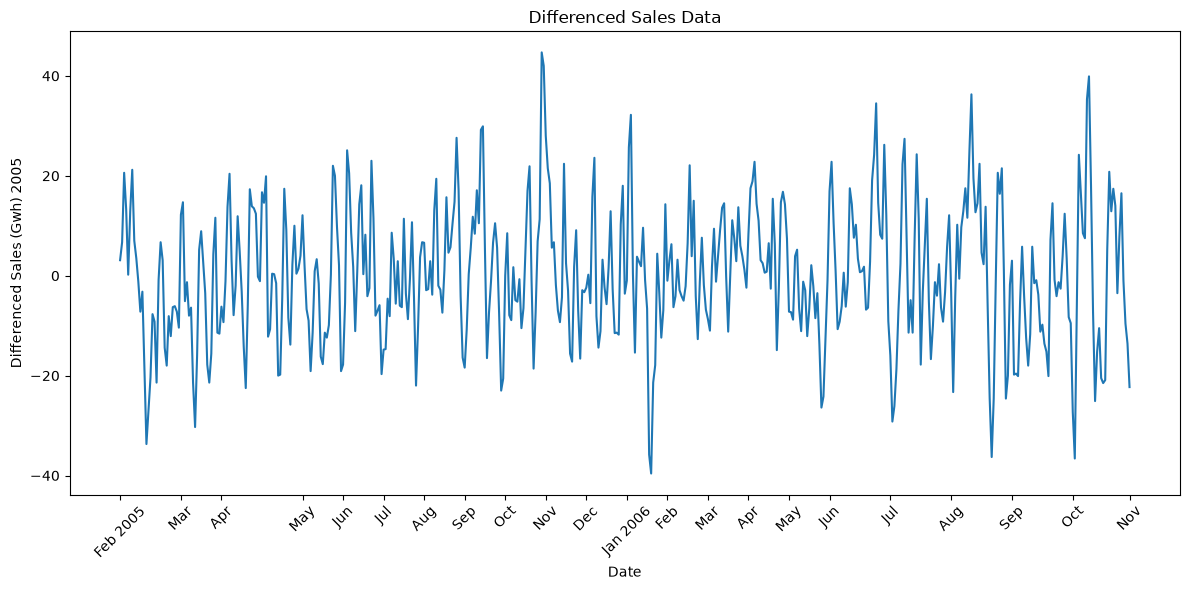

In [8]:
#Plot the differenced data
plt.figure(figsize=(12, 6))
plt.plot(sales_diff)
plt.title('Differenced Sales Data')
plt.xlabel('Date')
plt.ylabel('Differenced Sales (Gwh) 2005')

plt.xticks(
    [0,30,50,90,110,130,150,170,190,210,230,250,270,290,310,330,350,380,410,440,470,498],
    ['Feb 2005','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec',
     'Jan 2006','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']
)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Now, the time series looks stationary. However, we need to validate it.

In [9]:
# Test for stationarity of the transformed data
ADF_result = adfuller(sales_diff)
print(f'{"ADF Statistic":<15} {ADF_result[0]:>10.4f}')
print(f'{"p-value":<15} {ADF_result[1]:>10.4f}')

ADF Statistic     -10.5753
p-value             0.0000


A small **p-value** ($p\le0.05$) suggests that we can reject the null hypothesis. That is, we reject that **"there is a unit root"**, and the data is likely to be stationary.

---

Solving the previous. **Try it yourself**

If we used the adfuller test with the original data (before differencing) we can set the `regression` parameter to test different "orders of the time series".

- `c` (default) = order 0 (constant)

- `ct` = order 1 (constant + linear trend)

- `ctt` = order 2 (constant + quadratic trend)

In [10]:
# Test for stationarity of the original data (order 0: c)
ADF_result = adfuller(df['Sales'])
print(f'{"ADF Statistic":<15} {ADF_result[0]:>10.4f}')
print(f'{"p-value":<15} {ADF_result[1]:>10.4f}')

ADF Statistic      -1.5124
p-value             0.5274


In [11]:
# Test for stationarity of the original data (order 1: ct)
ADF_result = adfuller(df['Sales'], regression='ct')
print(f'{"ADF Statistic":<15} {ADF_result[0]:>10.4f}')
print(f'{"p-value":<15} {ADF_result[1]:>10.4f}')

ADF Statistic      -3.4694
p-value             0.0428


In [12]:
# Test for stationarity of the original data (order 2: ctt)
ADF_result = adfuller(df['Sales'], regression='ctt')
print(f'{"ADF Statistic":<15} {ADF_result[0]:>10.4f}')
print(f'{"p-value":<15} {ADF_result[1]:>10.4f}')

ADF Statistic      -2.9714
p-value             0.3090


In our example, only with `ct` did we get a small (statistically significant) p-value (0.0428).

This gives us a hint that we should apply first-order differencing to our time series if we want to achieve stationarity.

That is exactly what we did in **step 3**.

**Step 4: Plot Autocorrelation**

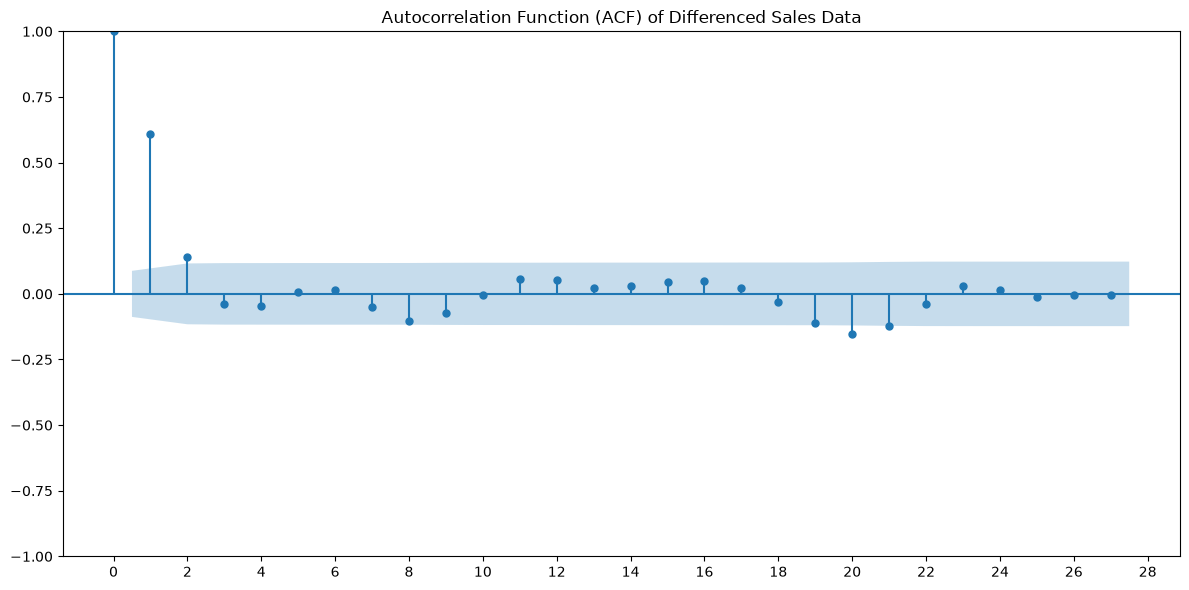

In [13]:
# The number of lags determine the range of values on the x-axis of the ACF and PACF plots.
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(sales_diff, ax=ax)
plt.title('Autocorrelation Function (ACF) of Differenced Sales Data')
plt.xticks(
    [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28],
    ['0','2','4','6','8','10','12','14','16','18','20','22','24','26','28']
)
plt.tight_layout()
plt.show()

Notice that there is a significant spike at a lag of 1 and 2 and much lower spikes for the subsequent lags. This means that this is partially correlated. There is a correlation (but not significant) at lag 3.

**Conclusion**: Moving Average Process and the order is 2. MA(2) because the significant drop to insignificant coefficient is after lag 2.

**Step5: Forecasting a Moving Average Process**

In [14]:
df_diff = pd.DataFrame({'sales_diff': sales_diff}, index=df.index[1:])

# We want to forecast the next 4 weeks of sales, so we will use the last 28 days of data to fit our model.
# 4 weeks x 7 days = 28 days
train = df_diff[:-28]
test = df_diff[-28:]

print(f'Training data shape: {train.shape}')
print(f'Testing data shape: {test.shape}')

Training data shape: (471, 1)
Testing data shape: (28, 1)


**Remember**: Moving average model only allows us to forecast **q** steps into the future, so to compute for the next 28 time steps, we need the rolling forecasting. We will use the function SARIMAX which was explained in the content video.

In [15]:
# Create the rolling_forecast, iterative method
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Perform rolling forecast on the given time series data.

    Parameters:
    df (pd.DataFrame): The input time series data.
    train_len (int): The length of the training data.
    horison (int): The number of steps to forecast.
    window (int): The size of the moving window for the forecast.
    method (str): The forecasting method to use ('mean', 'median', etc.).

    Returns:
    list: A list of forecasted values.
    """
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))
        return pred_mean
    
    elif method == "last":
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value
    
    elif method == "MA":
        pred_MA = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(0, 0, 2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(start=i, end=i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_MA.extend(oos_pred)
        return pred_MA
   

In **SARIMAX**, the parameter `order=(0,0,2)` means the model uses 0 autoregressive terms, no differencing, and 2 moving average terms - a pure MA(2) model.

In [16]:
# Train the baseline model and predict - historical mean and last known value
# Train using the moving average process and predict the next 28 steps
pred_df = test.copy()

TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, method="mean")
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, method="last")
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, method="MA")

pred_df["pred_mean"] = pred_mean
pred_df["pred_last_value"] = pred_last_value
pred_df["pred_MA"] = pred_MA

pred_df.head()

,sales_diff,pred_mean,pred_last_value,pred_MA
Date,,,,
2006-10-17,-36.6,0.126539,-27.3,-20.702583
2006-10-18,-6.9,0.126539,-27.3,-5.759659
2006-10-19,24.2,0.034038,-6.9,6.926750
2006-10-20,16.4,0.034038,-6.9,3.117339
2006-10-21,8.5,0.119368,16.4,2.812400


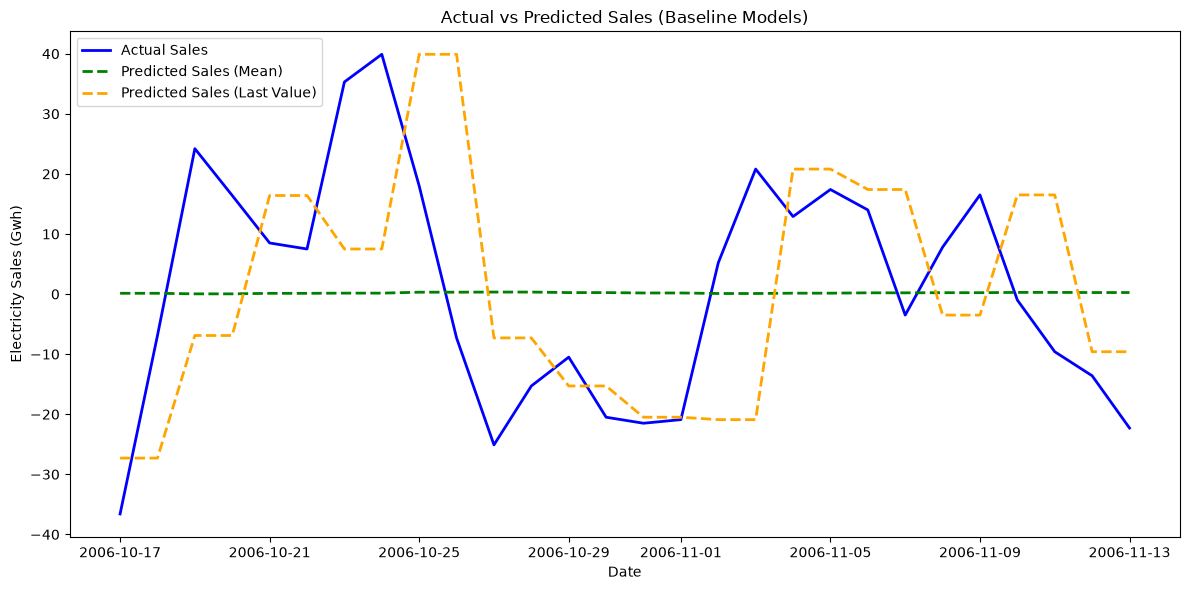

In [17]:
# Compare the actual to the baseline models
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pred_df["sales_diff"], label="Actual Sales", color='blue', linewidth=2)
ax.plot(pred_df["pred_mean"], label="Predicted Sales (Mean)", color='green', linestyle='--', linewidth=2)
ax.plot(pred_df["pred_last_value"], label="Predicted Sales (Last Value)", color='orange', linestyle='--', linewidth=2)

ax.legend(loc=2)

ax.set_xlabel('Date')
ax.set_ylabel('Electricity Sales (Gwh)')

plt.title('Actual vs Predicted Sales (Baseline Models)')

plt.tight_layout()
plt.show()

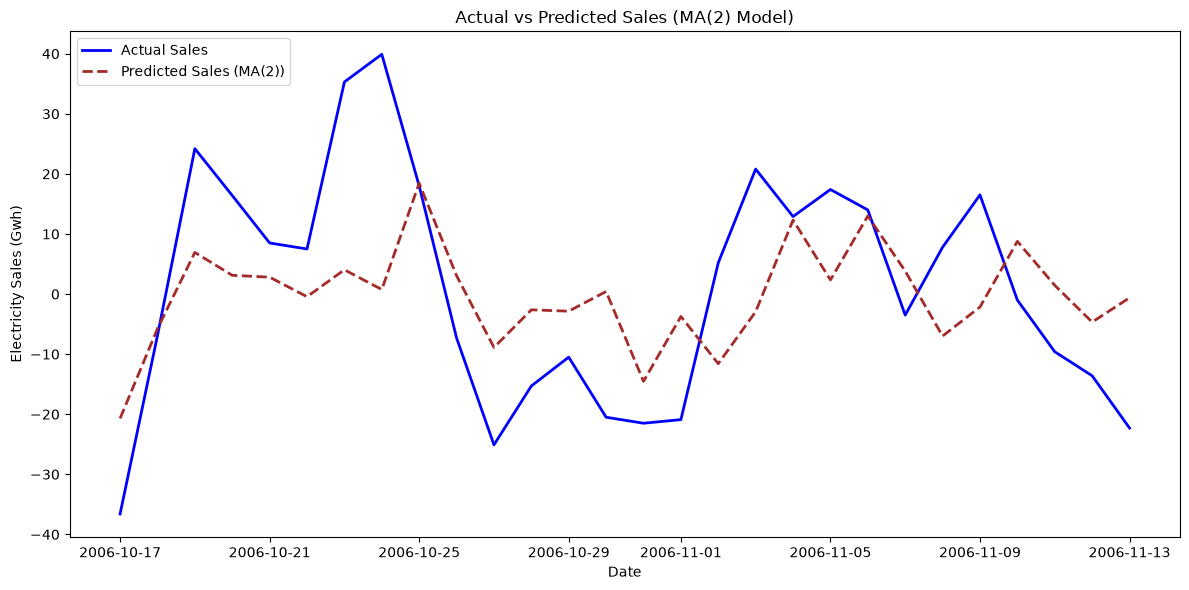

In [19]:
# Compare the actual to the MA(2) model
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pred_df["sales_diff"], label="Actual Sales", color='blue', linewidth=2)
ax.plot(pred_df["pred_MA"], label="Predicted Sales (MA(2))", color='brown', linestyle='--', linewidth=2)

ax.legend(loc=2)

ax.set_xlabel('Date')
ax.set_ylabel('Electricity Sales (Gwh)')

plt.title('Actual vs Predicted Sales (MA(2) Model)')

plt.tight_layout()
plt.show()

In [20]:
# Calculate the error metrics for the baseline models and the MA(2) model
mse_mean = mean_squared_error(pred_df["sales_diff"], pred_df["pred_mean"])
mse_last = mean_squared_error(pred_df["sales_diff"], pred_df["pred_last_value"])
mse_MA = mean_squared_error(pred_df["sales_diff"], pred_df["pred_MA"])

# Print the MSE results for each method
print(f"{'Forecast Method':<30} {'MSE':>15}")
print('-' * 46)
print(f'{"Mean Forecast":<30} {mse_mean:>15,.2f}')
print(f'{"Last Value Forecast":<30} {mse_last:>15,.2f}')
print(f'{"MA(2) Forecast":<30} {mse_MA:>15,.2f}')

Forecast Method                            MSE
----------------------------------------------
Mean Forecast                           362.61
Last Value Forecast                     419.69
MA(2) Forecast                          255.89


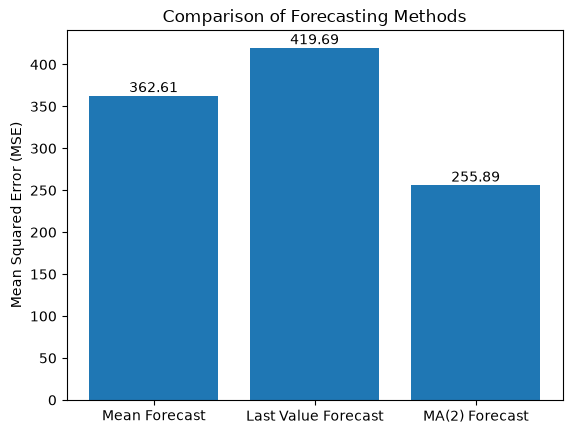

In [22]:
# Plot MSE values for each forecasting method for visual comparison
methods = ['Mean Forecast', 'Last Value Forecast', 'MA(2) Forecast']
mse_values = [mse_mean, mse_last, mse_MA]

plt.bar(methods, mse_values)
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Comparison of Forecasting Methods')

for i, v in enumerate(mse_values):
    plt.text(i, v + 0.5, f"{v:,.2f}", ha='center', va='bottom')

plt.show()

**Step 6: Inverse transform the prediction to bring them back to the original scale**

In [23]:
# Initialise the column with NaN values
df["pred_Sales"] = np.nan

# Get the last actual value before prediction starts
last_observed = df["Sales"].iloc[471]

# Compute the forecast (cumulative sum of MA(2) predictions)
forecast_values = last_observed + pred_df["pred_MA"].cumsum().values

# Assign the predicted values to the DataFrame safely using iloc
df.iloc[472:472 + len(forecast_values), df.columns.get_loc("pred_Sales")] = forecast_values

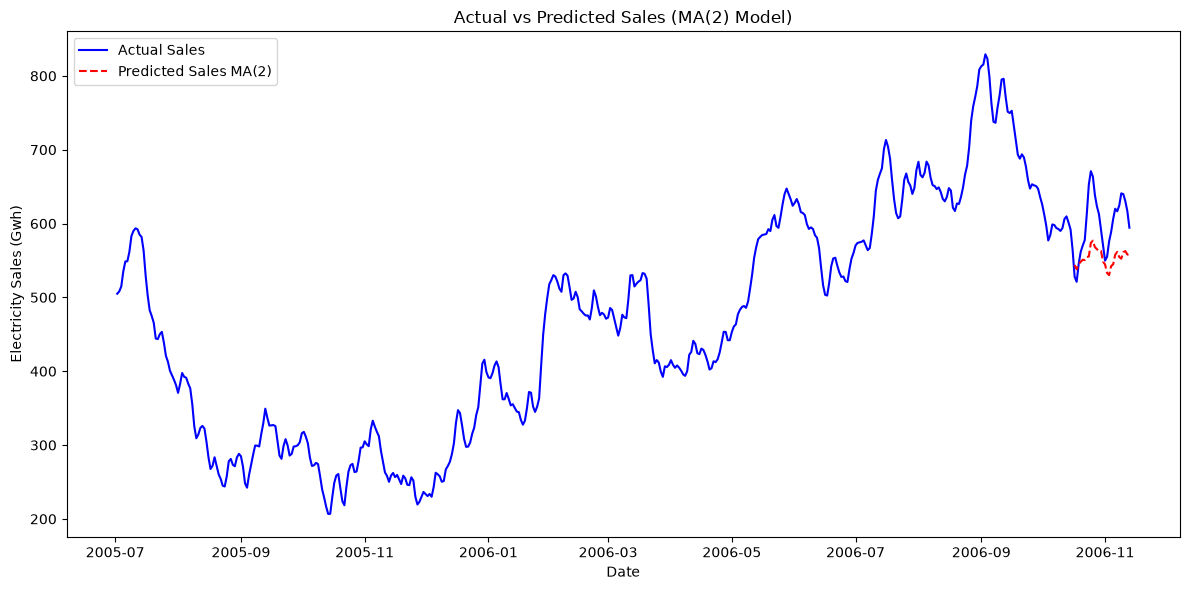

In [24]:
# Plot against the original data
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df["Sales"], "b-", label="Actual Sales")
ax.plot(df["pred_Sales"], "r--", label="Predicted Sales MA(2)")

plt.title('Actual vs Predicted Sales (MA(2) Model)')
ax.legend(loc=2)
ax.set_xlabel('Date')
ax.set_ylabel('Electricity Sales (Gwh)')

plt.tight_layout()
plt.show()

In [25]:
mae_MA_undiff = mean_absolute_error(df["Sales"].iloc[472:], df["pred_Sales"].iloc[472:])
print(f'Mean Absolute Error (MAE) for MA(2) model: {mae_MA_undiff:.2f}')

Mean Absolute Error (MAE) for MA(2) model: 48.60


**Takeaways**

- The ACF plot helped identify the appropriate lag (`q`) by showing where autocorrelations drop off.

- The MA model forecasted sales using past error terms, which works well when residuals show short-term memory.

- We reconstructed the forecasted values into the original scale using cumulative sums, since we worked on differenced data.

- Compared to naive methods (e.g. mean or last value) the MA model can better capture **short-term shock patterns**, especially in volatile datasets like electricity demand.

**Next steps: Assess Time Series Model Performance**

1. Use accuracy metrics like **MAE**, **MSE**, or **MAPE** to measure prediction error.

2. Analyse **residuals** - they should look like random noise if the model is well-fitted.

3. Visualise predictions vs actuals to spot trends, lags, or bias.

4. Apply **rolling forecasts or backtesting** to simulate how the model performs over time.

5. Think critically: is the model useful for the actual deciion-making context?